<a href="https://colab.research.google.com/github/Muhammad-Musharraf/Machine-Learning/blob/main/Loan_Approved_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [636]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [637]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [638]:
df=pd.read_csv("/content/drive/MyDrive/loan_data.csv")

In [639]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [640]:
df.shape

(45000, 14)

In [641]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [642]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [643]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [644]:
df.duplicated().sum()

np.int64(0)

In [645]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [646]:
# Remove Unnesssary Colums
df=df.drop(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership'],axis=1)

In [647]:
df.head()

,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [648]:
df.isnull().sum()

,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0
cb_person_cred_hist_length,0
credit_score,0
previous_loan_defaults_on_file,0
loan_status,0


In [649]:
df.dropna(inplace=True)

In [650]:
df.head()

,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [651]:
df.isnull().sum()

,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0
cb_person_cred_hist_length,0
credit_score,0
previous_loan_defaults_on_file,0
loan_status,0


In [652]:
df.rename(columns={"loan_amnt":"Loan Amount",	"loan_intent":"Loan Intent","loan_int_rate":"Loan interest Rate","loan_percent_income":"Loan percentage","cb_person_cred_hist_length":"Credit History",	"credit_score":"Credit Score","previous_loan_defaults_on_file":"Previous Loan",	"loan_status":"Loan Status"},inplace=True)

In [653]:
df.head()

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [654]:
df.dtypes

,0
Loan Amount,float64
Loan Intent,object
Loan interest Rate,float64
Loan percentage,float64
Credit History,float64
Credit Score,int64
Previous Loan,object
Loan Status,int64


In [655]:
df['Credit History']=df['Credit History'].astype(int)

In [656]:
df['Credit History'].dtype

dtype('int64')

#Check Unique Values of All Columns.

In [657]:
df['Credit History'].unique()

array([ 3,  2,  4,  8,  7,  6,  9, 10,  5, 11, 16, 15, 12, 13, 17, 14, 25,
       28, 27, 22, 19, 29, 23, 26, 20, 21, 30, 24, 18])

In [658]:
df['Credit Score'].unique()

array([561, 504, 635, 675, 586, 532, 701, 585, 544, 640, 621, 651, 573,
       708, 583, 670, 663, 694, 709, 679, 684, 662, 691, 600, 654, 626,
       607, 700, 553, 589, 681, 567, 669, 606, 582, 649, 602, 616, 631,
       637, 695, 620, 622, 645, 624, 570, 648, 652, 559, 623, 609, 579,
       688, 661, 562, 664, 564, 598, 557, 677, 690, 599, 604, 601, 634,
       671, 789, 538, 587, 683, 518, 617, 668, 673, 706, 536, 689, 595,
       584, 642, 614, 597, 625, 603, 643, 508, 505, 593, 686, 646, 697,
       615, 687, 650, 588, 658, 531, 665, 703, 594, 618, 574, 577, 653,
       630, 660, 639, 612, 628, 592, 580, 678, 672, 613, 566, 718, 484,
       699, 656, 659, 636, 554, 807, 578, 674, 608, 569, 629, 560, 548,
       667, 676, 581, 655, 551, 529, 666, 576, 633, 611, 657, 647, 542,
       692, 545, 540, 525, 537, 641, 539, 563, 712, 491, 590, 572, 528,
       638, 627, 596, 547, 507, 565, 693, 522, 632, 556, 499, 704, 503,
       714, 552, 555, 558, 521, 605, 571, 591, 719, 610, 535, 64

In [659]:
df['Loan Intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [660]:
df['Loan Amount'].unique()

array([35000.,  1000.,  5500., ..., 12229.,  2771.,  6665.])

In [661]:
df['Loan Status'].unique()

array([1, 0])

In [662]:
df['Loan percentage'].unique()

array([0.49, 0.08, 0.44, 0.53, 0.19, 0.37, 0.35, 0.13, 0.34, 0.3 , 0.27,
       0.25, 0.05, 0.24, 0.31, 0.26, 0.12, 0.18, 0.21, 0.43, 0.11, 0.4 ,
       0.32, 0.1 , 0.41, 0.22, 0.07, 0.02, 0.17, 0.51, 0.38, 0.33, 0.06,
       0.03, 0.28, 0.04, 0.09, 0.2 , 0.23, 0.15, 0.48, 0.5 , 0.14, 0.42,
       0.01, 0.46, 0.29, 0.39, 0.36, 0.16, 0.  , 0.57, 0.45, 0.52, 0.55,
       0.61, 0.62, 0.66, 0.54, 0.47, 0.56, 0.58, 0.63, 0.59])

In [663]:
df['Previous Loan'].unique()

array(['No', 'Yes'], dtype=object)

In [664]:
df['Loan interest Rate'].unique()

array([16.02, 11.14, 12.87, ..., 19.11, 19.8 , 16.92])

#Train-Test-Split

In [665]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [666]:
x=df.drop('Loan Status',axis=1)
y=df['Loan Status']

In [667]:
x

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan
0,35000.0,PERSONAL,16.02,0.49,3,561,No
1,1000.0,EDUCATION,11.14,0.08,2,504,Yes
2,5500.0,MEDICAL,12.87,0.44,3,635,No
3,35000.0,MEDICAL,15.23,0.44,2,675,No
4,35000.0,MEDICAL,14.27,0.53,4,586,No
...,...,...,...,...,...,...,...
44995,15000.0,MEDICAL,15.66,0.31,3,645,No
44996,9000.0,HOMEIMPROVEMENT,14.07,0.14,11,621,No
44997,2771.0,DEBTCONSOLIDATION,10.02,0.05,10,668,No
44998,12000.0,EDUCATION,13.23,0.36,6,604,No


In [668]:
y

,Loan Status
0,1
1,0
2,1
3,1
4,1
...,...
44995,1
44996,1
44997,1
44998,1


In [669]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [670]:
ohe=OneHotEncoder(drop='first',sparse_output=False,dtype=np.int32)

In [671]:
x_train_new=ohe.fit_transform(x_train[['Loan Intent']])

In [672]:
df.head()

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,35000.0,PERSONAL,16.02,0.49,3,561,No,1
1,1000.0,EDUCATION,11.14,0.08,2,504,Yes,0
2,5500.0,MEDICAL,12.87,0.44,3,635,No,1
3,35000.0,MEDICAL,15.23,0.44,2,675,No,1
4,35000.0,MEDICAL,14.27,0.53,4,586,No,1


In [673]:
x_train_new

array([[0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1],
       [0, 0, 0, 1, 0],
       ...,
       [0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0]], dtype=int32)

In [674]:
x_train_new.shape

(36000, 5)

In [675]:
x_test_new=ohe.fit_transform(x_test[['Loan Intent']])

In [676]:
x_test_new

array([[1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0],
       ...,
       [1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0]], dtype=int32)

#Label Encoding

In [677]:
from sklearn.preprocessing import LabelEncoder

In [678]:
le=LabelEncoder()

In [679]:
df['Previous Loan']=le.fit_transform(df['Previous Loan'])

In [680]:
df['Previous Loan']

,Previous Loan
0,0
1,1
2,0
3,0
4,0
...,...
44995,0
44996,0
44997,0
44998,0


#Data Scaling

In [681]:
num_cols = [
    'Loan Amount',
    'Loan interest Rate',
    'Loan percentage',
    'Credit Score',
    'Credit History'
]





In [682]:
from sklearn.preprocessing import StandardScaler


In [683]:
scaler = StandardScaler()


In [684]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()




In [685]:

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])


In [686]:
x_train

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan
25180,0.859025,PERSONAL,0.577910,0.119054,0.816732,-0.032444,No
12555,0.383393,VENTURE,0.286925,0.233921,-0.478914,0.524687,Yes
29153,2.285919,PERSONAL,-0.211430,-0.799885,1.334990,1.002227,Yes
23838,0.002888,EDUCATION,2.052907,-0.455283,0.298474,0.166531,No
35686,-0.399971,HOMEIMPROVEMENT,0.658182,-0.685018,-0.738043,1.459871,Yes
...,...,...,...,...,...,...,...
11284,0.165396,EDUCATION,-1.663014,-0.225548,-0.478914,-1.465066,Yes
44732,-0.587529,HOMEIMPROVEMENT,0.230066,0.348788,-0.478914,0.285916,No
38158,0.178396,VENTURE,-0.087677,0.463655,0.816732,0.385404,Yes
860,1.651744,DEBTCONSOLIDATION,2.337203,-0.340416,-0.738043,-0.569677,No


In [687]:
x_test

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan
37979,-0.330054,EDUCATION,-1.659669,-0.685018,1.075861,-0.629370,No
9911,-0.092238,EDUCATION,0.163172,0.233921,-0.478914,0.285916,Yes
43386,-0.726413,MEDICAL,1.297013,-0.110681,-0.478914,1.559358,No
13822,-0.726413,VENTURE,0.999338,-0.110681,-0.738043,-0.708960,Yes
44810,0.066306,HOMEIMPROVEMENT,1.474280,0.119054,1.334990,-0.927833,No
...,...,...,...,...,...,...,...
14572,0.700481,VENTURE,-0.338527,-0.340416,-0.997172,0.425199,No
30384,-0.452925,EDUCATION,1.822125,-0.340416,1.334990,-0.529882,Yes
36665,0.700481,EDUCATION,0.216687,0.463655,-0.738043,-0.370702,No
30569,-0.250782,MEDICAL,0.002628,0.923125,2.112377,1.240998,No


In [688]:
df.corr(numeric_only=True)

,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
Loan Amount,1.000000,0.146093,0.593011,0.042969,0.009074,-0.059009,0.107714
Loan interest Rate,0.146093,1.000000,0.125209,0.018008,0.011498,-0.181800,0.332005
Loan percentage,0.593011,0.125209,1.000000,-0.031868,-0.011483,-0.203252,0.384880
Credit History,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.022640,-0.014851
Credit Score,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.183005,-0.007647
Previous Loan,-0.059009,-0.181800,-0.203252,-0.022640,-0.183005,1.000000,-0.543096
Loan Status,0.107714,0.332005,0.384880,-0.014851,-0.007647,-0.543096,1.000000


<Axes: >

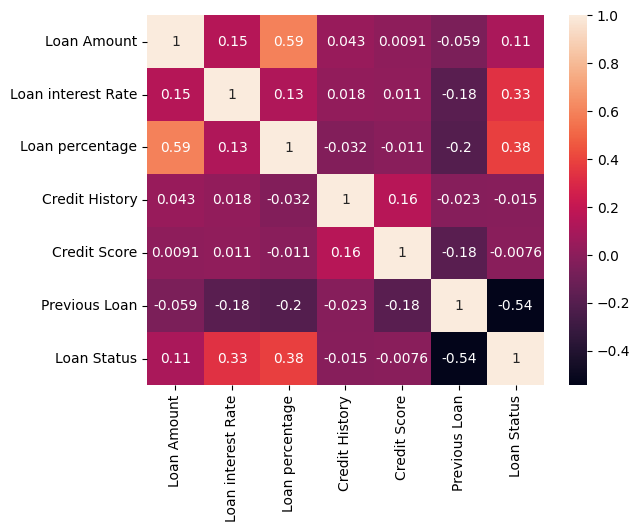

In [689]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [690]:
df.head()

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,35000.0,PERSONAL,16.02,0.49,3,561,0,1
1,1000.0,EDUCATION,11.14,0.08,2,504,1,0
2,5500.0,MEDICAL,12.87,0.44,3,635,0,1
3,35000.0,MEDICAL,15.23,0.44,2,675,0,1
4,35000.0,MEDICAL,14.27,0.53,4,586,0,1


In [691]:
df.head()

,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,35000.0,PERSONAL,16.02,0.49,3,561,0,1
1,1000.0,EDUCATION,11.14,0.08,2,504,1,0
2,5500.0,MEDICAL,12.87,0.44,3,635,0,1
3,35000.0,MEDICAL,15.23,0.44,2,675,0,1
4,35000.0,MEDICAL,14.27,0.53,4,586,0,1


In [692]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

In [693]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [694]:

rfc=RandomForestClassifier()
bgc=BaggingClassifier()
etc=ExtraTreesClassifier()
xgc=XGBClassifier()



In [695]:

classifiers={
'RFC':rfc,
'BGC':bgc,
'ETC':etc,
'XGB':xgc
}


In [696]:

# Define train_classifier function with confusion matrix display and additional metrics
def train_classifier(classifier, x_train, y_train, x_test, y_test, name):

  # Train the classifier
  classifier.fit(x_train, y_train)

  # Make predictions
  y_pred = classifier.predict(x_test)

  # Calculate metrics
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, average='weighted')
  recall = recall_score(y_test, y_pred, average='weighted')
  f1 = f1_score(y_test, y_pred, average='weighted')

  # Generate and display confusion matrix
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)

  disp.plot(cmap=plt.cm.Blues)
  plt.title(f"Confusion Matrix for {name}")
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.show()

  return accuracy, precision, recall, f1

In [697]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for name, clf in classifiers.items():
    # Train the classifier and get metrics
    current_accuracy, current_precision, current_recall, current_f1 = train_classifier(
        clf, x_train, y_train, x_test, y_test, name
    )

    # Store scores
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    recall_scores.append(current_recall)
    f1_scores.append(current_f1)

    # Print metrics
    print(f'Name: {name}')
    print(f'Accuracy: {current_accuracy}')
    print(f'Precision: {current_precision}')
    print(f'Recall: {current_recall}')
    print(f'F1 Score: {current_f1}')
    print('----------------------------')


ValueError: could not convert string to float: 'PERSONAL'